## PULSAR NULLING FRACTION CALCULATOR

This notebook visualises how a pulsar's nulling fraction changes over time using results produced by `nf_calculations.py`. It fits a linear trend to two independent nulling fraction estimators — the **Bayesian method** and the **Histogram Scaling (HS) method** — and produces a four-panel figure showing the number of pulse profiles, the signal-to-noise proxy, and both nulling fraction time series with their best-fit lines and confidence bands.

In [3]:
# Required packages: pip install numpy matplotlib scipy

# --- Configuration ---
pulsar_name = 'J1559-5545'     # Change this to your pulsar name
data_dir    = 'pulsar_results' # Path to the directory containing results folders

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import datetime
%matplotlib inline
from scipy.optimize import curve_fit

### READ IN THE OUTPUT FILE FROM NF_CALCULATIONS.PY:

Loads the main results file. Each column corresponds to a different quantity recorded per observation:

<table style="margin-left:0">
  <thead><tr><th>Row</th><th>Content</th></tr></thead>
  <tbody>
    <tr><td>0</td><td>Modified Julian Date (MJD) of each observation</td></tr>
    <tr><td>1</td><td>Bayesian nulling fraction estimate</td></tr>
    <tr><td>2</td><td>Lower uncertainty on the Bayesian nulling fraction</td></tr>
    <tr><td>3</td><td>Upper uncertainty on the Bayesian nulling fraction</td></tr>
    <tr><td>4</td><td>Signal-to-noise proxy</td></tr>
    <tr><td>5</td><td>Number of pulse profiles (rotations) in the observation</td></tr>
    <tr><td>6</td><td>Histogram Scaling (HS) nulling fraction</td></tr>
    <tr><td>7</td><td>Maximum number of consecutive nulls detected</td></tr>
  </tbody>
</table>

In [5]:
unzipped = np.loadtxt(f'{data_dir}/{pulsar_name}/{pulsar_name}.txt')

### READ IN THE OUTPUT FILE FOR THE LIST OF NULLS AND NON NULLS:

Loads a second file containing the lengths of consecutive null and non-null pulse-train sequences (one list per observation). These sequences are used to compute the mean train length across all observations, which sets the effective number of independent trials needed for the binomial uncertainty calculation in the next section.

In [6]:
with open(f'{data_dir}/{pulsar_name}/{pulsar_name}_consecutive_nulls_and_non.txt', 'r') as f:
    all_nulls = eval(f.readline().strip())
    all_non_nulls = eval(f.readline().strip())

In [7]:
flat_all_nulls = [num for sublist in all_nulls for num in sublist]
flat_all_non_nulls = [num for sublist in all_non_nulls for num in sublist]
mean_train = np.mean(flat_all_nulls + flat_all_non_nulls)

### CREATE A LIST OF THE NUMBER OF PROFILES IN THE OBSERVATIONS:

Extracts the number of individual pulse profiles recorded in each observation (row 5 of the results array). This count is used when estimating how many statistically independent null/non-null trials each observation contains.

In [8]:
n_prof_list = unzipped[5]

### APPROXIMATION OF THE EXPECTED NULLING FRACTION OF THE PULSAR:

Computes a single weighted-average nulling fraction across all observations, using the mean of the lower and upper Bayesian uncertainties as weights (so better-constrained observations contribute more). This value (`nf_exp`) is used as the assumed true nulling fraction when computing binomial uncertainties in the following cells.

In [9]:
nf_exp = np.average(unzipped[1], weights=np.mean([unzipped[2],unzipped[3]],axis=0))
print(f'Approx. nulling fraction across all data: {round(nf_exp,3)}')

Approx. nulling fraction across all data: 0.257


### BAYESIAN NULLING FRACTION MEASUREMENT UNCERTAINTY:

Computes a **binomial uncertainty** for each observation. The pulsar is modelled as repeatedly switching between null and non-null states, so each observation contains roughly `n_trials = N_profiles / mean_train_length` independent switching trials. For a binomial proportion with `n_trials` trials and expected proportion `nf_exp`, the standard deviation is:

```
binom_unc_nf = sqrt(n_trials * nf_exp * (1 - nf_exp)) / n_trials
```

This captures how much the measured nulling fraction could vary from observation to observation purely because of the finite number of independent pulse trains observed.

In [10]:
bayes_uncertainties = np.array([unzipped[2],unzipped[3]])

In [11]:
binom_unc_nf_list = []

for u in range(len(n_prof_list)):
    #n_trials = n_prof_list[u] / mean_of_max_nulls
    n_trials = n_prof_list[u] / mean_train
    binom_unc = np.sqrt(n_trials*nf_exp*(1-nf_exp))
    binom_unc_nf = binom_unc / n_trials
    binom_unc_nf_list.append(binom_unc_nf)

### COMBINE BINOMIAL UNCERTAINTY AND BAYESIAN NULLING FRACTION MEASUREMENT UNCERTAINTY:

Adds the binomial uncertainty (from the previous cell) and the Bayesian measurement uncertainty in quadrature to produce a total combined uncertainty for each observation:

```
total_unc = sqrt(binom_unc² + bayes_unc²)
```

This is done separately for the lower and upper Bayesian error bars. A scalar mean combined uncertainty (`uncertainties_mean`) is also computed for use as the sigma weighting in the linear curve fit.

In [12]:
lower_unc = []
upper_unc = []

for d in range(len(unzipped[2])):
    lower_unc.append(np.sqrt(binom_unc_nf_list[d]**2 + unzipped[2][d]**2))

for d in range (len(unzipped[3])):
    upper_unc.append(np.sqrt(binom_unc_nf_list[d]**2 + unzipped[3][d]**2))
    
lower_unc = np.array(lower_unc)
upper_unc = np.array(upper_unc)

uncertainties = np.array([lower_unc,upper_unc])

uncertainties_mean = np.sqrt((uncertainties[0]**2 + uncertainties[1]**2)/2)

### CREATE A BEST FIT LINE:

Defines a simple linear model **f(x) = a·x + b** that will be fitted to each nulling fraction time series. The gradient `a` represents the rate of change of nulling fraction per day, and the intercept `b` gives the nulling fraction at the reference epoch (the first observation MJD, after the time axis has been zeroed).

In [13]:
def linear_model(x, a, b):
    return a * x + b

### CONVERT ABSOLUTE MJD TO RELATIVE-TO-THE-FIRST-MJD:

Shifts the time axis so that t = 0 corresponds to the first observation. Working in relative time keeps the numerical values small, which improves the stability of the curve fitting and makes the fitted intercept directly interpretable as the nulling fraction at the start of the observing campaign.

In [14]:
mjd_delta = [mjd-unzipped[0][0] for mjd in unzipped[0]] # MJD - FIRST MJD

### CALCULATE THE BEST FIT LINE FOR THE BAYESIAN TECHNIQUE:

Uses `scipy.optimize.curve_fit` to fit the linear model to the Bayesian nulling fractions, weighted by the combined uncertainties (`uncertainties_mean`). Setting `absolute_sigma=True` means the uncertainties are treated as true measurement errors rather than relative weights. The output is the best-fit gradient `a_fit` and intercept `b_fit`, together with their standard deviations extracted from the diagonal of the returned covariance matrix.

In [15]:
# Perform the curve fit
params, covariance = curve_fit(linear_model, mjd_delta, unzipped[1], sigma=uncertainties_mean, absolute_sigma=True)

# Extract the best-fit parameters
a_fit, b_fit = params

# Calculate the standard deviations (uncertainties) for the parameters
a_std_dev, b_std_dev = np.sqrt(np.diag(covariance))

In [16]:
print(f'BAYES a_fit (gradient in NF / Day): {a_fit:.2e} +- {a_std_dev:.2e} ({a_fit/a_std_dev:.2e} sigma)')
print(f'BAYES b_fit (intercept in NF): {b_fit:.2e} +- {b_std_dev:.2e}')

print(f'BAYES a_fit (gradient in NF / Year): {a_fit*365.25:.2e} +- {a_std_dev*365.35:.2e} ({a_fit/a_std_dev:.2e} sigma)')


BAYES a_fit (gradient in NF / Day): 4.59e-05 +- 2.34e-05 (1.96e+00 sigma)
BAYES b_fit (intercept in NF): 2.31e-01 +- 2.32e-02
BAYES a_fit (gradient in NF / Year): 1.68e-02 +- 8.57e-03 (1.96e+00 sigma)


### CALCULATE THE CONFIDENCE INTERVAL FOR THE BAYESIAN BEST FIT LINE:

Computes a classical frequentist confidence band around the best-fit line using the residual standard error `s_y_x` (the scatter of the data points around the fit) and a leverage term that accounts for how far each point is from the mean of the x values. The band naturally widens towards the edges of the data range, where the fit is less well constrained. This band is used in the plot as an alternative to the covariance-based band computed later.

In [17]:
n_term = len(unzipped[1])
#term_2 = (x* - x_)**2

y_sum = 0.0

for n in range(n_term):
    y_sum += (unzipped[1][n] - (a_fit*mjd_delta[n] + b_fit))**2.0


s_y_x = ((y_sum)/(n_term-2.0))**0.5

In [18]:
def s_y_hat_func(x_wanted,x_data):
    
    term_1 = 1/len(x_data)
    
    term_2 = (x_wanted - np.mean(x_data))**2
    
    term_3 = 0.0
    for n in range(len(x_data)):
        term_3 += (x_data[n] - np.mean(x_data))**2.0
    
    full_term = (term_1 + (term_2/term_3))**0.5
    
    return full_term

In [19]:
mjd_delta = [mjd-unzipped[0][0] for mjd in unzipped[0]]
fit_unc = np.linspace(np.min(mjd_delta),np.max(mjd_delta), 100)

s_y_hat = []

for f in fit_unc:
    s_y_hat.append(s_y_hat_func(f,mjd_delta))
    
conf_interv = np.array(s_y_hat)*s_y_x

### TAKE UNCERTAINTY FROM HISTOGRAM SCALING TECHNIQUE AND COMBINE WITH BINOMIAL UNCERTAINTY:

Derives the measurement uncertainty on each Histogram Scaling (HS) nulling fraction from Poisson counting statistics — the number of null pulses counted in an observation scales as `sqrt(NF * N_profiles)`, so the fractional uncertainty is `sqrt(NF * N) / N`. This is then combined in quadrature with the binomial uncertainty to give the total uncertainty used to weight the HS curve fit.

In [20]:
# UNCERTAINTIES FOR THE HISTOGRAM SCALING METHOD

hs_and_binom_unc = []
hs_unc = []

for d in range(len(unzipped[2])):
    hs_unc.append(np.sqrt(unzipped[6][d]*n_prof_list[d]) / n_prof_list[d])
    hs_and_binom_unc.append(np.sqrt(binom_unc_nf_list[d]**2 + hs_unc[d]**2))

hs_and_binom_unc = np.array(hs_and_binom_unc)
hs_unc = np.array(hs_unc)

### CALCULATE THE BEST FIT LINE FOR THE HISTOGRAM SCALING TECHNIQUE:

Repeats the weighted linear curve fit, this time applied to the Histogram Scaling nulling fractions. Using the combined HS + binomial uncertainties as weights allows a direct comparison of the fitted gradient and intercept between the two estimators, providing an independent check on whether the nulling fraction is evolving over time.

In [21]:
# Perform the curve fit
params_w, covariance_w = curve_fit(linear_model, mjd_delta, unzipped[6], sigma=hs_and_binom_unc, absolute_sigma=True)

# Extract the best-fit parameters
a_fit_w, b_fit_w = params_w

# Calculate the standard deviations (uncertainties) for the parameters
a_std_dev_w, b_std_dev_w = np.sqrt(np.diag(covariance_w))

In [22]:
print(f'HS a_fit (gradient in NF / Day): {a_fit_w:.2e} +- {a_std_dev_w:.2e}')
print(f'HS b_fit (intercept): {b_fit_w:.2e} +- {b_std_dev_w:.2e}')

print(f'HS a_fit (gradient in NF / Year): {a_fit_w*365.25:.2e} +- {a_std_dev_w*365.35:.2e} ({a_fit_w/a_std_dev_w:.2e} sigma)')

HS a_fit (gradient in NF / Day): 3.50e-05 +- 1.73e-05
HS b_fit (intercept): 4.20e-01 +- 1.65e-02
HS a_fit (gradient in NF / Year): 1.28e-02 +- 6.32e-03 (2.02e+00 sigma)


### CALCULATE THE CONFIDENCE INTERVAL FOR THE HISTOGRAM SCALING BEST FIT LINE:

Reuses the leverage function `s_y_hat_func` and the same x-grid as the Bayesian confidence interval to compute an equivalent classical confidence band for the HS best-fit line. Using the same grid ensures the two bands span identical date ranges, making visual comparison between the panels straightforward.

In [23]:
n_term_w = len(unzipped[6])

y_sum_w = 0.0

for n_w in range(n_term_w):
    y_sum_w += (unzipped[6][n_w] - (a_fit_w * mjd_delta[n_w] + b_fit_w))**2.0

s_y_x_w = ((y_sum_w) / (n_term_w - 2.0))**0.5

In [24]:
conf_interv_w = np.array(s_y_hat)*s_y_x_w

### FIND UPPER AND LOWER LIMITS FOR THE NULLING FRACTION PLOTS BELOW:

Finds the most extreme upper and lower values across both estimators, including their full error bars, so that both nulling fraction panels can share identical y-axis limits. A 2% buffer is added above and below to prevent data points from sitting flush against the axis edge.

In [25]:
### ylims for both NF plots:
highest = max(np.max(unzipped[1]+uncertainties[1]), np.max(unzipped[6]+hs_and_binom_unc)) 
lowest = min(np.min(unzipped[1]-uncertainties[0]), np.min(unzipped[6]-hs_and_binom_unc)) 
buffer = 0.02 * (highest-lowest)

ylim_upp = highest + buffer
ylim_low = lowest - buffer

### COVARIANCE-BASED 2σ CONFIDENCE INTERVALS:

Computes a **covariance-propagation** confidence band for each best-fit line. For every point on the fitted line, the variance of the predicted value is calculated from the fit covariance matrix using the Jacobian of the linear model (J = [x, 1]ᵀ):

```
var(ŷ) = Jᵀ · Cov · J
```

The shaded band in the plot shows the region within which the true mean response is expected to lie with ~95% confidence, assuming the parameter uncertainties are Gaussian. Unlike the classical band computed earlier, this approach uses the full parameter covariance (including the correlation between gradient and intercept) rather than the residual scatter.

In [26]:
# Covariance-based 2σ confidence band for the Bayesian fit
x = np.linspace(np.min(mjd_delta), np.max(mjd_delta), 200)
y_hat = a_fit * x + b_fit
J = np.vstack([x, np.ones_like(x)])
var_y = np.einsum('ij,jk,ik->i', J.T, covariance, J.T)
sigma_y = np.sqrt(var_y)
lower_2sigma = y_hat - 2 * sigma_y
upper_2sigma = y_hat + 2 * sigma_y
x_abs = x + unzipped[0][0]

In [27]:
# Compute best-fit line and 2σ band for the weighted fit (bottom panel)

# Create a grid of x values (same spacing as before)
x_w = np.linspace(np.min(mjd_delta), np.max(mjd_delta), 200)

# Predicted line (best fit)
y_hat_w = a_fit_w * x_w + b_fit_w

# 1σ uncertainty for the mean response
J_w = np.vstack([x_w, np.ones_like(x_w)])             # shape (2, N)
var_y_w = np.einsum('ij,jk,ik->i', J_w.T, covariance_w, J_w.T)  # diag(J^T Cov J)
sigma_y_w = np.sqrt(var_y_w)

# 2σ confidence band
lower_2sigma_w = y_hat_w - 2 * sigma_y_w
upper_2sigma_w = y_hat_w + 2 * sigma_y_w

# Convert to absolute MJD for plotting (match the bottom panel’s x-axis)
x_abs_w = x_w + unzipped[0][0]

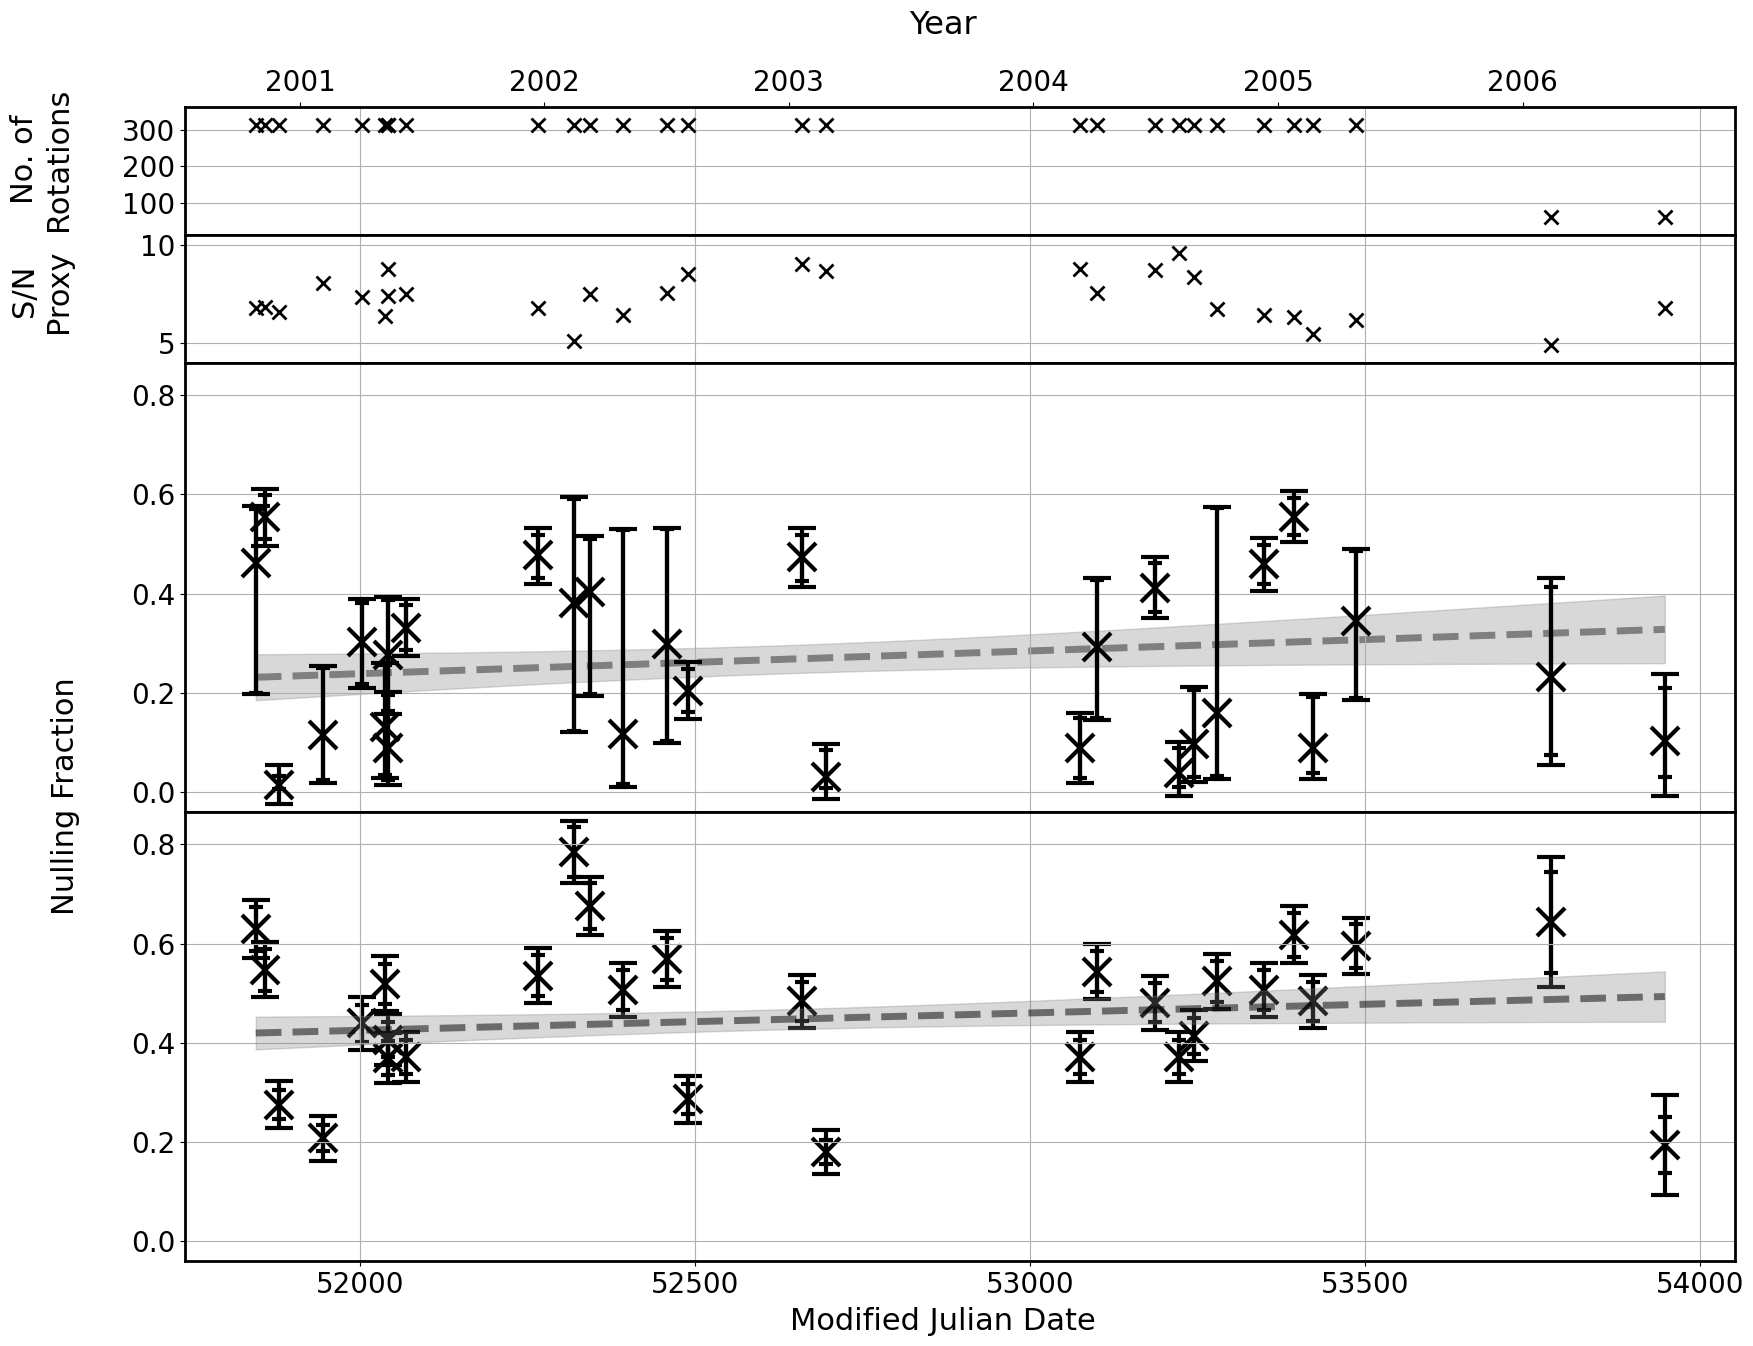

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import datetime
import matplotlib.gridspec as gridspec

def mjd_to_date(mjd):
    jd = mjd + 2400000.5
    return datetime.datetime(1858, 11, 17) + datetime.timedelta(days=jd - 2400000.5)

def first_day_of_year_mjd(year):
    first_day = datetime.datetime(year, 1, 1)
    jd = (first_day - datetime.datetime(1858, 11, 17)).days + 2400000.5
    return jd - 2400000.5

fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(4, 1, height_ratios=[2, 2, 7, 7], hspace=0.0)

# Top panel — number of rotations
ax0 = plt.subplot(gs[0])
plt.plot(unzipped[0], unzipped[5], 'kx', markersize=10, mew=2)
plt.grid(True)
ax0.set_ylim(np.nanmin(unzipped[5]) - ((np.nanmax(unzipped[5]) - np.nanmin(unzipped[5])) * 0.2),
             np.nanmax(unzipped[5]) + ((np.nanmax(unzipped[5]) - np.nanmin(unzipped[5])) * 0.2))
plt.gca().set_xticklabels([])

ax0_top = ax0.twiny()
ax0_top.set_xlim(ax0.get_xlim())
years = [mjd_to_date(mjd).year for mjd in unzipped[0]]
unique_years = sorted(set(years))
min_year, max_year = min(unique_years), max(unique_years)
unique_years = list(range(min_year + 1, max_year + 1))
first_day_mjds = [first_day_of_year_mjd(year) for year in unique_years]
ax0_top.set_xticks(first_day_mjds)
ax0_top.set_xticklabels([str(year) for year in unique_years])
plt.setp(ax0_top.get_xticklabels(), rotation=0, ha='center')
ax0_top.tick_params(axis='x', labelsize=20)

# Second panel — S/N proxy
ax1 = plt.subplot(gs[1])
plt.plot(unzipped[0], unzipped[4], 'kx', markersize=10, mew=2)
plt.grid(True)
ax1.set_ylim(np.nanmin(unzipped[4]) - ((np.nanmax(unzipped[4]) - np.nanmin(unzipped[4])) * 0.2),
             np.nanmax(unzipped[4]) + ((np.nanmax(unzipped[4]) - np.nanmin(unzipped[4])) * 0.2))
plt.gca().set_xticklabels([])

# Third panel — BPE nulling fraction
ax3 = plt.subplot(gs[2])
plt.gca().set_xticklabels([])
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.errorbar(unzipped[0], unzipped[1], yerr=uncertainties, fmt='kx', markersize=20, capsize=10, lw=3, mew=3)
plt.errorbar(unzipped[0], unzipped[1], yerr=bayes_uncertainties, fmt='k,', capsize=5, lw=3, mew=3)
plt.ylim(ylim_low, ylim_upp)
plt.grid(True)

x_range = np.linspace(min(unzipped[0]), max(unzipped[0]), 100)
x_range_new = np.linspace(min(mjd_delta), max(mjd_delta), 100)
plt.plot(x_range, linear_model(x_range_new, a_fit, b_fit), color='k', linewidth=5, linestyle='--', alpha=0.5, zorder=-100)
plt.fill_between(x_abs, lower_2sigma, upper_2sigma, color='grey', alpha=0.3, label='2σ band (covariance)')

# Fourth panel — Histogram Scaling nulling fraction
ax4 = plt.subplot(gs[3])
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.errorbar(unzipped[0], unzipped[6], yerr=hs_and_binom_unc, fmt='kx', markersize=20, capsize=10, lw=3, mew=3, zorder=1)
plt.errorbar(unzipped[0], unzipped[6], yerr=hs_unc, fmt='k,', capsize=5, lw=3, mew=3, zorder=1)
plt.ylim(ylim_low, ylim_upp)
plt.grid(True)

plt.plot(x_range, linear_model(x_range_new, a_fit_w, b_fit_w), color='k', linewidth=5, linestyle='--', alpha=0.5, zorder=3)
plt.fill_between(x_abs_w, lower_2sigma_w, upper_2sigma_w, color='grey', alpha=0.3, label='2σ band (covariance, weighted)', zorder=2)

for ax in [ax0, ax1, ax3, ax4]:
    ax.tick_params(axis='both', labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(2)

fig.text(0.053, 0.845, 'No. of\nRotations', ha='center', va='center', rotation='vertical', size=22)
fig.text(0.053, 0.757, 'S/N\nProxy', ha='center', va='center', rotation='vertical', size=22)
fig.text(0.065, 0.42, 'Nulling Fraction', ha='center', va='center', rotation='vertical', size=22)
fig.text(0.504, 0.934, 'Year', ha='center', va='center', rotation='horizontal', size=23)
fig.text(0.504, 0.07, 'Modified Julian Date', ha='center', va='center', rotation='horizontal', size=22)

plt.savefig(f'{pulsar_name}_nf_evolution.png', facecolor='white')
plt.show()